**Problem Statement**
Online book retailers and publishing houses face a critical challenge in predicting a book's commercial success before its release or during its early market presence. With thousands of new titles published annually, making accurate revenue forecasts and inventory decisions can mean the difference between profitable operations and costly overstock or stockouts. This project addresses this business need by framing the problem as a regression task to predict a book's popularity and market performance, using "reviews count" as a proxy for commercial success and reader engagement from best selling online books data.

Success will be measured by RMSE (Root Mean Square Error) as the primary metric, providing interpretable error margins in terms of review counts, with R² serving as a secondary metric to explain the variance captured by our model. From a business perspective, a successful model would enable publishers to identify potential bestsellers earlier in their lifecycle, optimize initial print runs, and make data-driven decisions about marketing investments. The business KPI would be a 15% improvement in inventory turnover rate, a 10% reduction in unsold inventory and 10% improvement in marketing ROI, achieved through more accurate sales forecasting based on predicted review volumes.

**Data Source:** [Kaggle.com - Complete Book Sale Analysis](https://www.kaggle.com/code/aryankaisth/complete-book-sales-analysis/input)

Saving best sellin books 2023.csv to best sellin books 2023.csv
First 5 rows of the dataset:
   id                                          Book name  \
0  #1  Atomic Habits: An Easy & Proven Way to Build G...   
1  #2    Iron Flame (Standard Edition) (The Empyrean, 2)   
2  #3                                              Spare   
3  #4                                        Fourth Wing   
4  #5                                    The Woman in Me   

                             Author              Rating  reviews count  \
0                       James Clear  4.8 out of 5 stars         145747   
1                    Rebecca Yarros  4.7 out of 5 stars         395512   
2  Prince Harry  The Duke of Sussex  4.5 out of 5 stars         116101   
3                    Rebecca Yarros  4.8 out of 5 stars         472618   
4                    Britney Spears  4.4 out of 5 stars          51520   

        form   price Reading age  Print Length   Publishing date  \
0  Hardcover  $18.88         NaN 

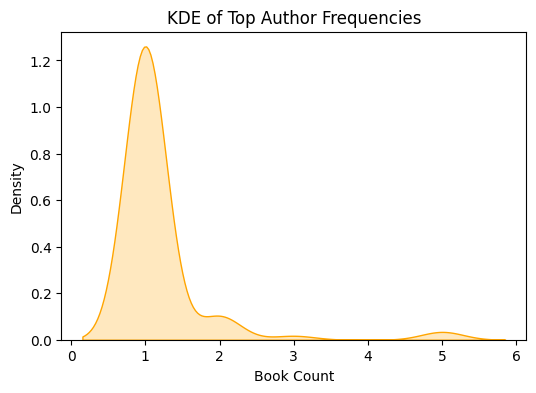



Unique rating values: ['4.8 out of 5 stars' '4.7 out of 5 stars' '4.5 out of 5 stars'
 '4.4 out of 5 stars' '4.6 out of 5 stars' '4.9 out of 5 stars'
 '4.2 out of 5 stars' '4.3 out of 5 stars' '4.1 out of 5 stars']


Rating Value Counts:
rating
4.8    28
4.7    17
4.6    15
4.9    12
4.4    11
4.5    10
4.2     4
4.3     2
4.1     1
Name: count, dtype: int64




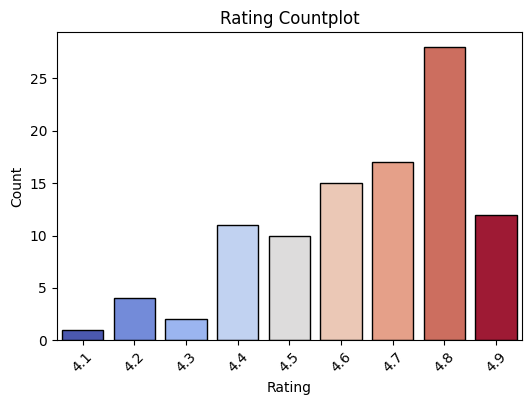



0    145747
1    395512
2    116101
3    472618
4     51520
Name: reviews count, dtype: int64




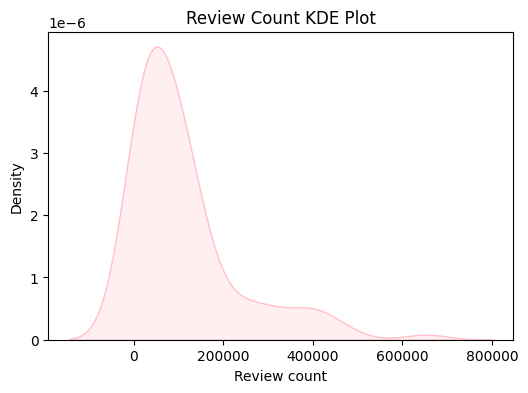



Skewness of reviews count: 1.9551683885411815
Kurtosis of reviews count: 4.089610629513073




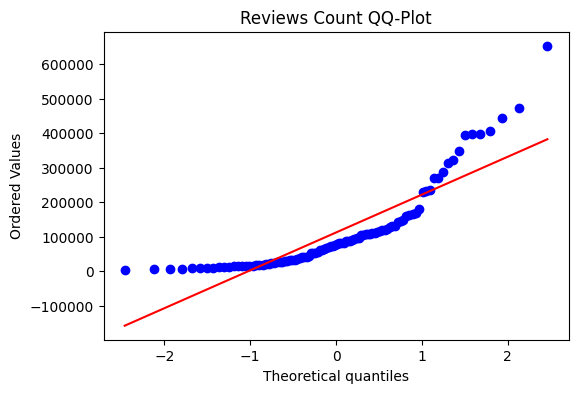

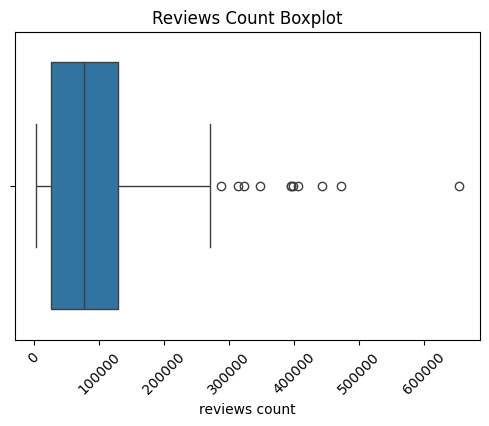




Shapiro–Wilk Normality Test (Reviews Count)
H0: Data follows a normal distribution.
H1: Data does not follow a normal distribution.

Shapiro statistic : 0.772
P-value           : 0.00000
Significance level: 0.05

Decision   : Reject H0
Inference  : Data is NOT normally distributed.


Number of uniques values in Form: 4




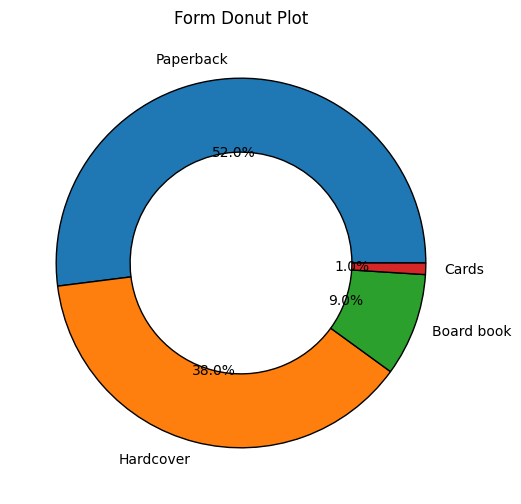

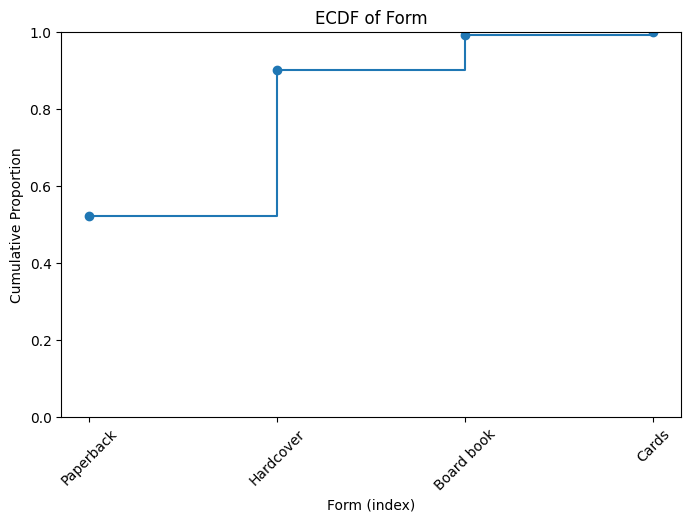



0    $18.88
1    $11.05
2    $11.99
3    $13.62
4    $11.37
Name: price, dtype: object


Sample prices after cleaning:
97     5.26
78     9.82
33     8.64
55    17.18
20    12.80
Name: price, dtype: float64




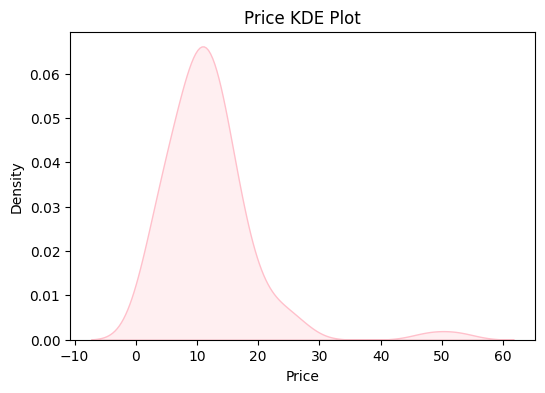



Skewness of Price: 2.635643608928299
Kurtosis of Price: 11.407127623615482




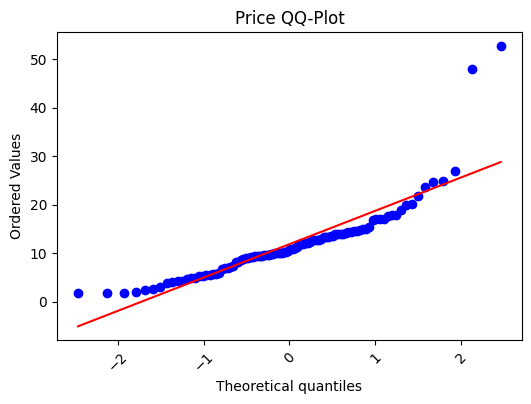

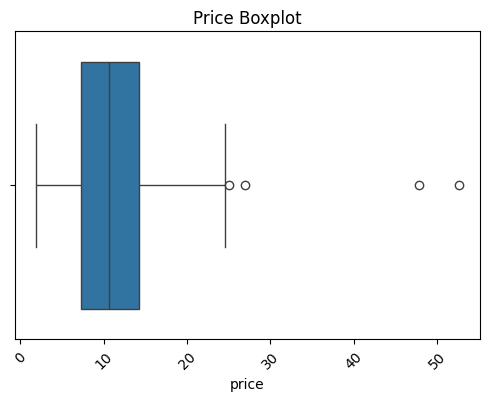




Shapiro–Wilk Normality Test (Price)
H0: Data follows a normal distribution.
H1: Data does not follow a normal distribution.

Shapiro statistic : 0.788
P-value           : 0.00000
Significance level: 0.05

Decision   : Reject H0
Inference  : Data is NOT normally distributed.




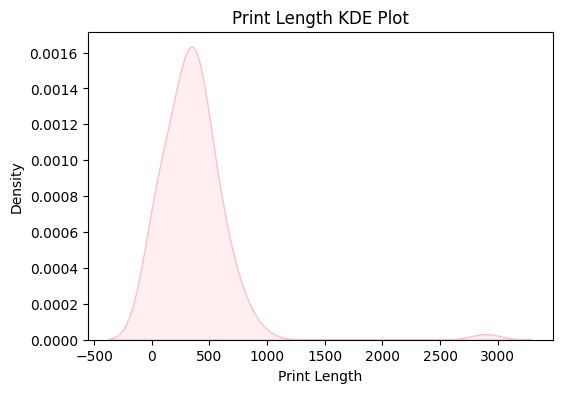

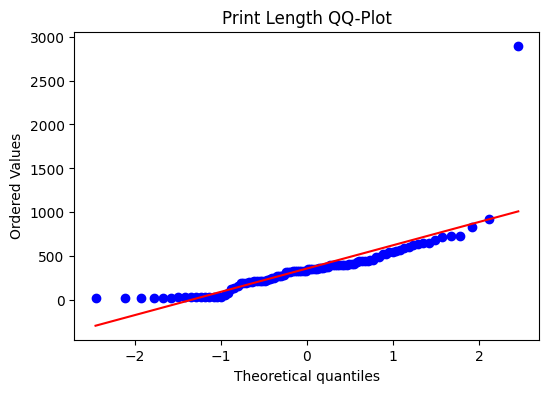

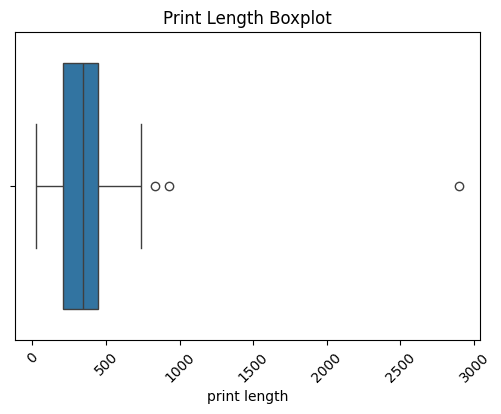




Shapiro–Wilk Normality Test (Print Length)
H0: Data follows a normal distribution.
H1: Data does not follow a normal distribution.

Shapiro statistic : 0.641
P-value           : 0.00000
Significance level: 0.05

Decision   : Reject H0
Inference  : Data is NOT normally distributed.


Number of uniques values in Genre: 16




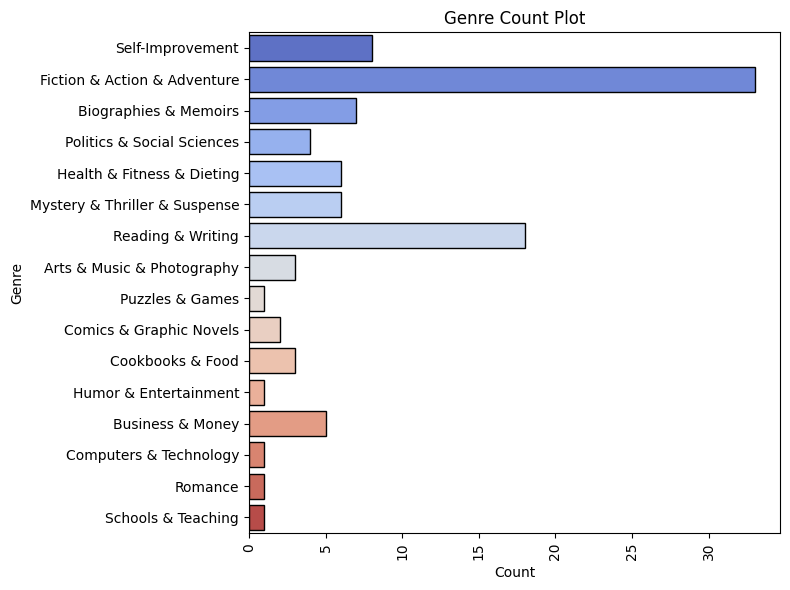

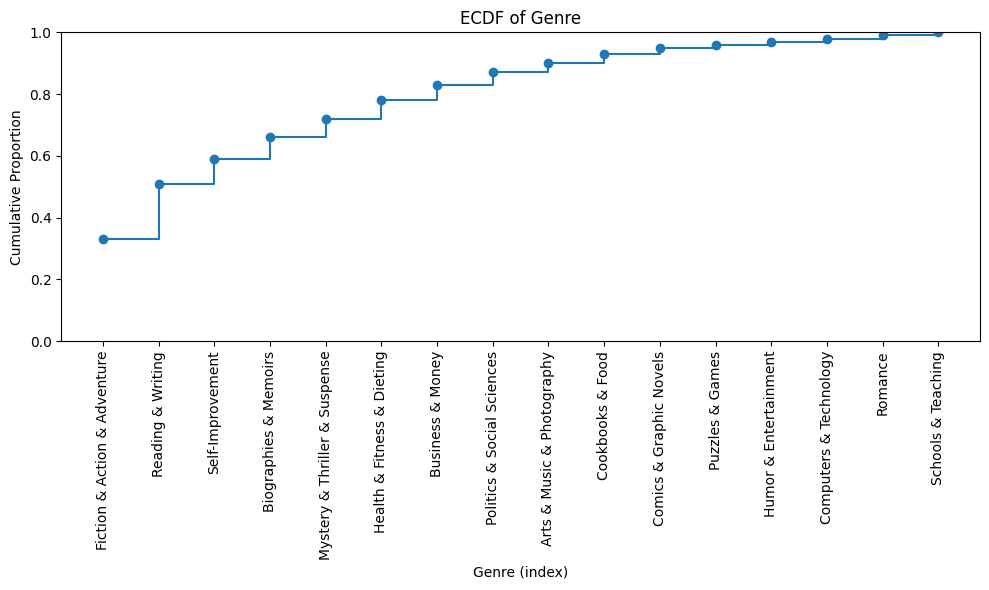



Data type of publishing date: object
0          16/10/2018
1          07/11/2023
2    January 10, 2023
3          17/09/2024
4    October 24, 2023
5       April 5, 2022
6          01/09/2000
7          08/09/2015
8          18/10/2022
9          28/03/2023
Name: publishing date, dtype: object


Publishing date value counts:
publishing date
02/06/2020            4
October 24, 2023      2
April 5, 2022         2
16/10/2018            2
September 27, 2022    2
                     ..
March 21, 2023        1
23/10/2018            1
June 1, 2024          1
27/08/2019            1
 July 17, 2018        1
Name: count, Length: 93, dtype: int64


Sample dates after cleaning:
63   2023-09-19
93   2016-05-31
52   2023-07-07
48   2023-02-07
27   1996-09-15
Name: publishing date, dtype: datetime64[ns]




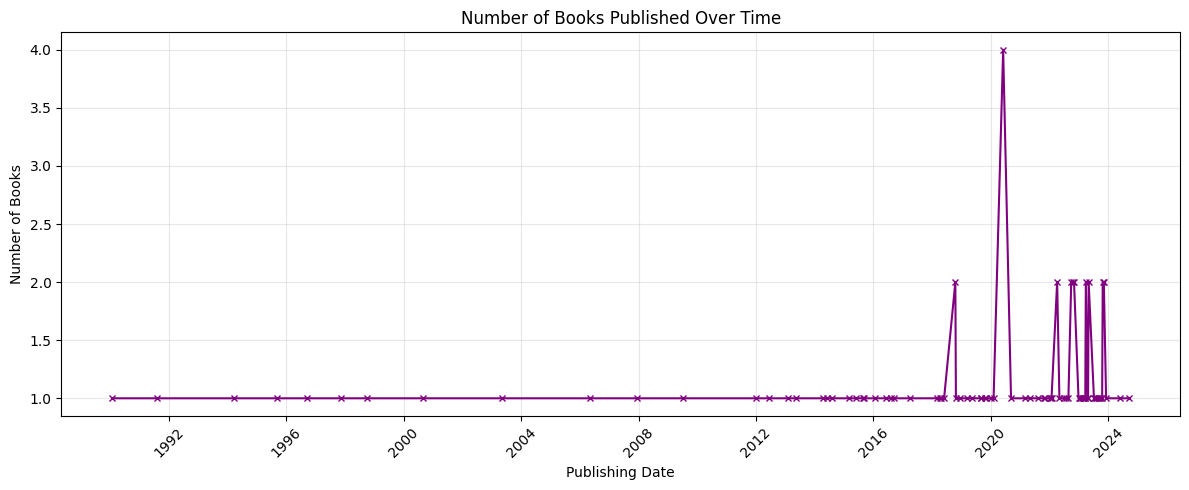


Analysis complete!


In [ ]:
from google.colab import files
uploaded = files.upload()

import numpy as np              # Provides numerical operations and array handling
import pandas as pd             # Used for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt # Creates basic plots and visualizations
import seaborn as sns           # Provides advanced statistical data visualizations
from scipy import stats         # Offers statistical functions and probability distributions

# FIX: Uncomment and properly define the raw variable
# First, let's find the uploaded file name
import io

# Get the filename from uploaded files
filename = list(uploaded.keys())[0]

# Read the uploaded file
raw = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    encoding='latin1'
)

# OR if you're using a specific file path, uncomment this:
# raw = pd.read_csv(
#    r'/kaggle/input/top-selling-books-data2023-2025/best sellin books 2023.csv',
#    encoding='latin1'
# )

# Creating deep copy of the data
df = raw.copy(deep=True)

# Preview of data
print("First 5 rows of the dataset:")
print(df.head(5))
print("\n" + "="*60 + "\n")

# Shape of data
print(f'Shape of data: {df.shape}')
print("\n" + "="*60 + "\n")

# Check for dtypes
print("DataFrame Info:")
df.info()
print("\n" + "="*60 + "\n")

# Summary of dataset
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*60 + "\n")

# Check for duplicates
print(f'Total duplicates in the dataset: {df.duplicated().sum()}')
print("\n" + "="*60 + "\n")

print(f'Total null values in the dataset: \n{df.isna().sum()}')
print("\n" + "="*60 + "\n")

# Lower casing the columns name
df.columns = df.columns.str.lower()

# FIX: Use double quotes inside f-strings to avoid syntax errors
print(f"Number of uniques ids: {df['id'].nunique()}")
print("\n" + "="*60 + "\n")

print(df['id'].head(5))
print("\n" + "="*60 + "\n")

# Clean ID column
df = df.assign(
    id = df['id'].str.replace('#', '', regex=False).astype(int)
)

#print(f"Number of uniques values in Book name: {df['author'].nunique()}")
print(f"Number of uniques values in Book name: {df['book name'].nunique()}")
print("\n" + "="*60 + "\n")
print(f"Number of unique authors: {df['author'].nunique()}")
print("\n" + "="*60 + "\n")

# Authors with more than two books available in the dataset
print("Authors with multiple books:")
print(df[df['author'].duplicated(keep=False)]['author'])
print("\n" + "="*60 + "\n")

# Frequency of Authors
print("Top 9 Authors by Frequency:")
print(df['author'].value_counts().nlargest(9).to_frame('count'))
print("\n" + "="*60 + "\n")

# Get author counts
counts = df['author'].value_counts()

# KDE plot
plt.figure(figsize=(6, 4))
sns.kdeplot(
    counts.values,
    fill=True,
    color='orange'
)

plt.title('KDE of Top Author Frequencies')
plt.xlabel('Book Count')
plt.ylabel('Density')

plt.show()
print("\n" + "="*60 + "\n")

# Unique values in rating
print(f"Unique rating values: {df['rating'].unique()}")
print("\n" + "="*60 + "\n")

# Cleaning the ratings
df = df.assign(
    rating = df['rating'].str.split().str[0].astype(float)
)

# Value counts
print("Rating Value Counts:")
print(df['rating'].value_counts())
print("\n" + "="*60 + "\n")

# Let's visualize the countplots of Rating

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x='rating',
    hue='rating',
    palette='coolwarm',
    edgecolor='black',
    legend=False
)

ax.set_title('Rating Countplot')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

plt.show()
print("\n" + "="*60 + "\n")

print(df['reviews count'].head(5))
print("\n" + "="*60 + "\n")

# Convert reviews count to numeric if needed
df['reviews count'] = pd.to_numeric(df['reviews count'], errors='coerce')

# Kde plot for Review Count

fig, ax = plt.subplots(figsize=(6, 4))

sns.kdeplot(
    data=df,
    x='reviews count',
    fill=True,
    color='pink'
)
ax.set_title('Review Count KDE Plot')
ax.set_xlabel('Review count')

plt.show()
print("\n" + "="*60 + "\n")

# FIX: Use double quotes in f-strings
print(f'Skewness of reviews count: {df["reviews count"].skew()}')
print(f'Kurtosis of reviews count: {df["reviews count"].kurt()}')
print("\n" + "="*60 + "\n")

# QQ-Plot for Review Count

fig, ax = plt.subplots(figsize=(6, 4))

stats.probplot(
    df['reviews count'].dropna(),
    plot=ax,
    dist='norm'
)
ax.set_title('Reviews Count QQ-Plot')

plt.show()
print("\n" + "="*60 + "\n")

# Boxplot for Review Count

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df,
    x='reviews count',
    ax=ax
)

ax.set_title('Reviews Count Boxplot')
ax.tick_params(axis='x', rotation=45)

plt.show()
print("\n" + "="*60 + "\n")

data = df['reviews count'].dropna()

# Shapiro–Wilk normality test (limit to first 5000 samples if dataset is large)
if len(data) > 5000:
    data = data.sample(n=5000, random_state=42)

statistic, p_value = stats.shapiro(data)

# alpha
alpha = 0.05

print("\n" + "="*55)
print("Shapiro–Wilk Normality Test (Reviews Count)")
print("="*55)
print("H0: Data follows a normal distribution.")
print("H1: Data does not follow a normal distribution.\n")

print(f"Shapiro statistic : {statistic:.3f}")
print(f"P-value           : {p_value:.5f}")
print(f"Significance level: {alpha}\n")
if p_value < alpha:
    print("Decision   : Reject H0")
    print("Inference  : Data is NOT normally distributed.")
else:
    print("Decision   : Fail to reject H0")
    print("Inference  : Data appears approximately normal.")
print("\n" + "="*60 + "\n")

print(f"Number of uniques values in Form: {df['form'].nunique()}")
print("\n" + "="*60 + "\n")

# Let's visualize the Donut Plot of Form

# Count values of form
counts = df['form'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

# Donut chart
ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4, edgecolor='black')
)

ax.set_title('Form Donut Plot')

plt.show()
print("\n" + "="*60 + "\n")

# Sorted counts
counts = df['form'].value_counts().sort_values(ascending=False)

# Compute cumulative proportion
ecdf = counts.cumsum() / counts.sum()

# Plot ECDF
plt.figure(figsize=(8, 5))
plt.step(range(len(counts)), ecdf, where='post')
plt.scatter(range(len(counts)), ecdf)

plt.title('ECDF of Form')
plt.xlabel('Form (index)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(len(counts)), counts.index, rotation=45)
plt.ylim(0, 1)

plt.show()
print("\n" + "="*60 + "\n")

print(df['price'].head(5))
print("\n" + "="*60 + "\n")

# Let's clean the price feature
df = df.assign(
    price = df['price'].str.replace('$', '', regex=False).astype(float)
)
print("Sample prices after cleaning:")
print(df['price'].sample(5))
print("\n" + "="*60 + "\n")

# Kde plot for Price

fig, ax = plt.subplots(figsize=(6, 4))

sns.kdeplot(
    data=df,
    x='price',
    fill=True,
    color='pink'
)
ax.set_title('Price KDE Plot')
ax.set_xlabel('Price')

plt.show()
print("\n" + "="*60 + "\n")

print(f'Skewness of Price: {df["price"].skew()}')
print(f'Kurtosis of Price: {df["price"].kurt()}')
print("\n" + "="*60 + "\n")

# QQ-Plot for Price

fig, ax = plt.subplots(figsize=(6, 4))

stats.probplot(
    df['price'].dropna(),
    plot=ax,
    dist='norm'
)
ax.set_title('Price QQ-Plot')
ax.tick_params(axis='x', rotation=45)

plt.show()
print("\n" + "="*60 + "\n")

# Boxplot for price

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df,
    x='price',
    ax=ax
)

ax.set_title('Price Boxplot')
ax.tick_params(axis='x', rotation=45)

plt.show()
print("\n" + "="*60 + "\n")

data = df['price'].dropna()

# Shapiro–Wilk normality test (limit to first 5000 samples if dataset is large)
if len(data) > 5000:
    data = data.sample(n=5000, random_state=42)

statistic, p_value = stats.shapiro(data)

# alpha
alpha = 0.05

print("\n" + "="*55)
print("Shapiro–Wilk Normality Test (Price)")
print("="*55)
print("H0: Data follows a normal distribution.")
print("H1: Data does not follow a normal distribution.\n")

print(f"Shapiro statistic : {statistic:.3f}")
print(f"P-value           : {p_value:.5f}")
print(f"Significance level: {alpha}\n")
if p_value < alpha:
    print("Decision   : Reject H0")
    print("Inference  : Data is NOT normally distributed.")
else:
    print("Decision   : Fail to reject H0")
    print("Inference  : Data appears approximately normal.")
print("\n" + "="*60 + "\n")

# Check if 'print length' column exists
if 'print length' in df.columns:
    # Kde plot for Print Length

    fig, ax = plt.subplots(figsize=(6, 4))

    sns.kdeplot(
        data=df,
        x='print length',
        fill=True,
        color='pink'
    )
    ax.set_title('Print Length KDE Plot')
    ax.set_xlabel('Print Length')

    plt.show()
    print("\n" + "="*60 + "\n")

    # QQ-Plot for Print Length

    fig, ax = plt.subplots(figsize=(6, 4))

    stats.probplot(
        df['print length'].dropna(),
        plot=ax,
        dist='norm'
    )
    ax.set_title('Print Length QQ-Plot')

    plt.show()
    print("\n" + "="*60 + "\n")

    # Boxplot for Print Length

    fig, ax = plt.subplots(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x='print length',
        ax=ax
    )

    ax.set_title('Print Length Boxplot')
    ax.tick_params(axis='x', rotation=45)

    plt.show()
    print("\n" + "="*60 + "\n")

    data = df['print length'].dropna()

    # Shapiro–Wilk normality test (limit to first 5000 samples if dataset is large)
    if len(data) > 5000:
        data = data.sample(n=5000, random_state=42)

    statistic, p_value = stats.shapiro(data)

    # alpha
    alpha = 0.05

    print("\n" + "="*55)
    print("Shapiro–Wilk Normality Test (Print Length)")
    print("="*55)
    print("H0: Data follows a normal distribution.")
    print("H1: Data does not follow a normal distribution.\n")

    print(f"Shapiro statistic : {statistic:.3f}")
    print(f"P-value           : {p_value:.5f}")
    print(f"Significance level: {alpha}\n")
    if p_value < alpha:
        print("Decision   : Reject H0")
        print("Inference  : Data is NOT normally distributed.")
    else:
        print("Decision   : Fail to reject H0")
        print("Inference  : Data appears approximately normal.")
    print("\n" + "="*60 + "\n")
else:
    print("Column 'print length' not found in the dataset. Skipping these plots.")
    print("\n" + "="*60 + "\n")

print(f"Number of uniques values in Genre: {df['genre'].nunique()}")
print("\n" + "="*60 + "\n")

# Let's visualize the countplots of Genre

fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    data=df,
    y='genre',
    hue='genre',
    palette='coolwarm',
    edgecolor='black',
    legend=False
)

ax.set_title('Genre Count Plot')
ax.set_xlabel('Count')
ax.set_ylabel('Genre')
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
print("\n" + "="*60 + "\n")

# Get sorted counts
counts = df['genre'].value_counts().sort_values(ascending=False)

# Compute cumulative proportion
ecdf = counts.cumsum() / counts.sum()

# Plot ECDF
plt.figure(figsize=(10, 6))
plt.step(range(len(counts)), ecdf, where='post')
plt.scatter(range(len(counts)), ecdf)

plt.title('ECDF of Genre')
plt.xlabel('Genre (index)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(len(counts)), counts.index, rotation=90)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()
print("\n" + "="*60 + "\n")

print(f"Data type of publishing date: {df['publishing date'].dtype}")
print(df['publishing date'].head(10))
print("\n" + "="*60 + "\n")

print("Publishing date value counts:")
print(df['publishing date'].value_counts())
print("\n" + "="*60 + "\n")

# Let's clean the datetime feature
dates = pd.to_datetime(df['publishing date'], errors='coerce', dayfirst=True)

mask = dates.isna()

if mask.any():
    dates.loc[mask] = pd.to_datetime(
        df.loc[mask, 'publishing date'],
        format='%B %d, %Y',  # e.g., February 21, 2023
        errors='coerce'
    )

# Save back
df['publishing date'] = dates

print("Sample dates after cleaning:")
print(df['publishing date'].sample(5))
print("\n" + "="*60 + "\n")

# Books per date (drop NA dates)
books_per_date = df['publishing date'].dropna().value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(
    books_per_date.index,
    books_per_date.values,
    marker='x',
    color='purple',
    linestyle='-',
    markersize=4
)

plt.title('Number of Books Published Over Time')
plt.xlabel('Publishing Date')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")


ENHANCED EDA FOR REVIEW COUNT PREDICTION

----------------------------------------
UNIVARIATE ANALYSIS - TARGET VARIABLE
----------------------------------------


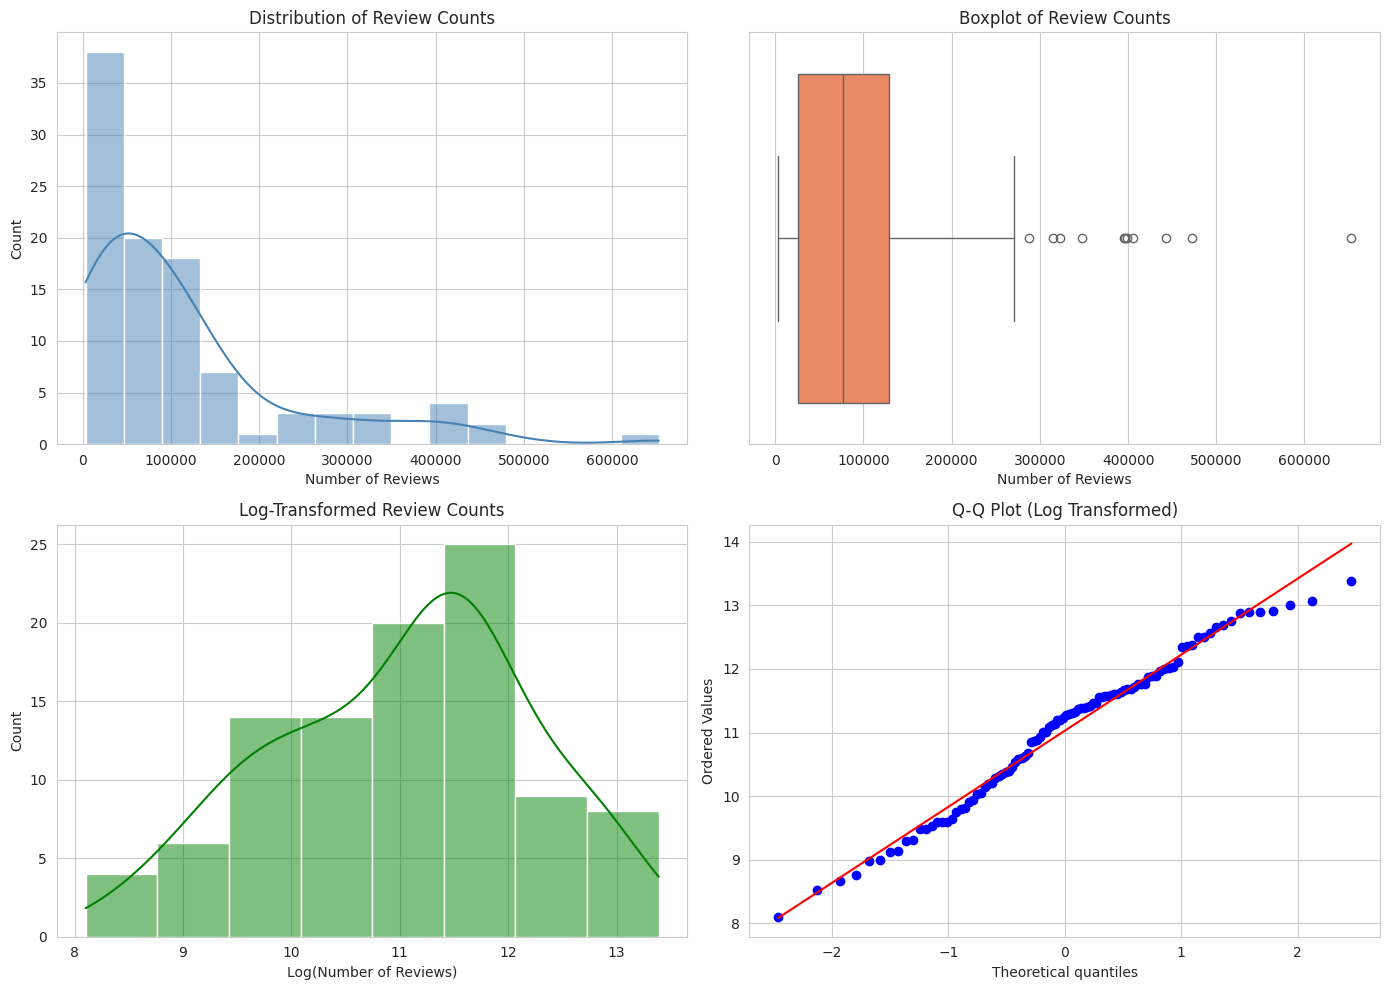

Target variable statistics:
Mean: 111732.84
Median: 77085.00
Std Dev: 123318.55
Skewness: 1.96
Kurtosis: 4.09

----------------------------------------
BIVARIATE ANALYSIS - RELATIONSHIPS WITH TARGET
----------------------------------------


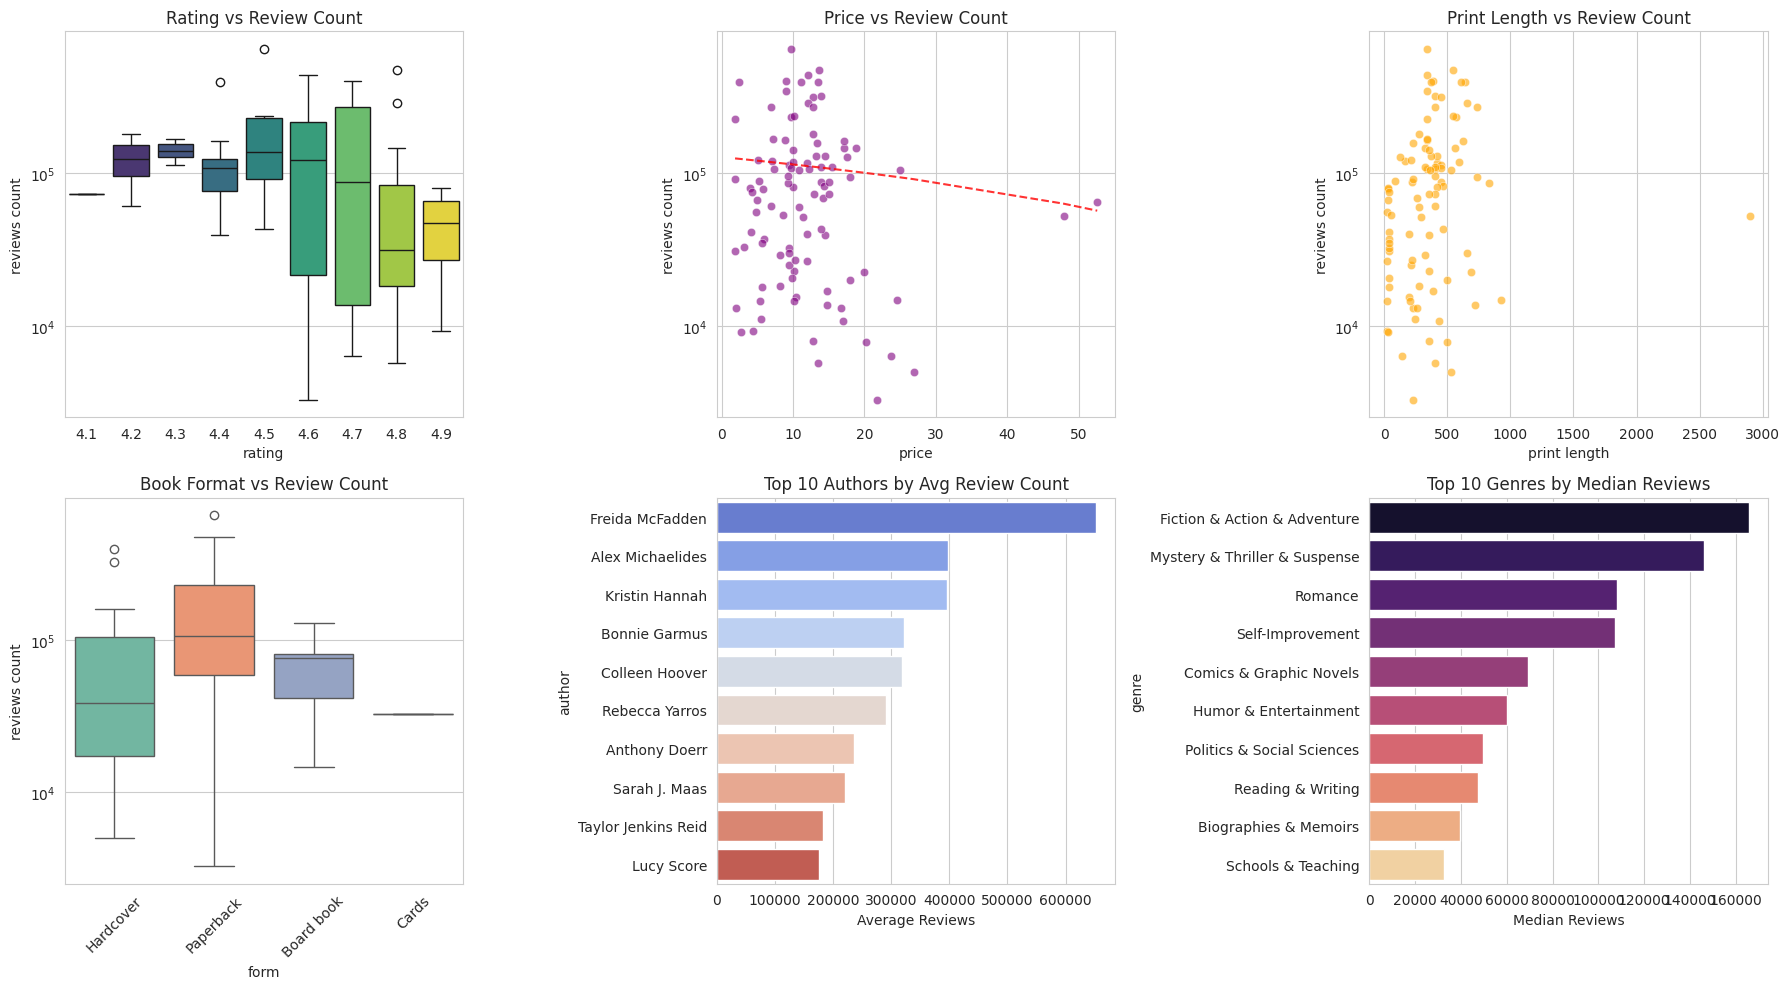


----------------------------------------
CORRELATION ANALYSIS
----------------------------------------
Correlation with Review Count:
print length: 0.144
price: -0.084
rating: -0.233


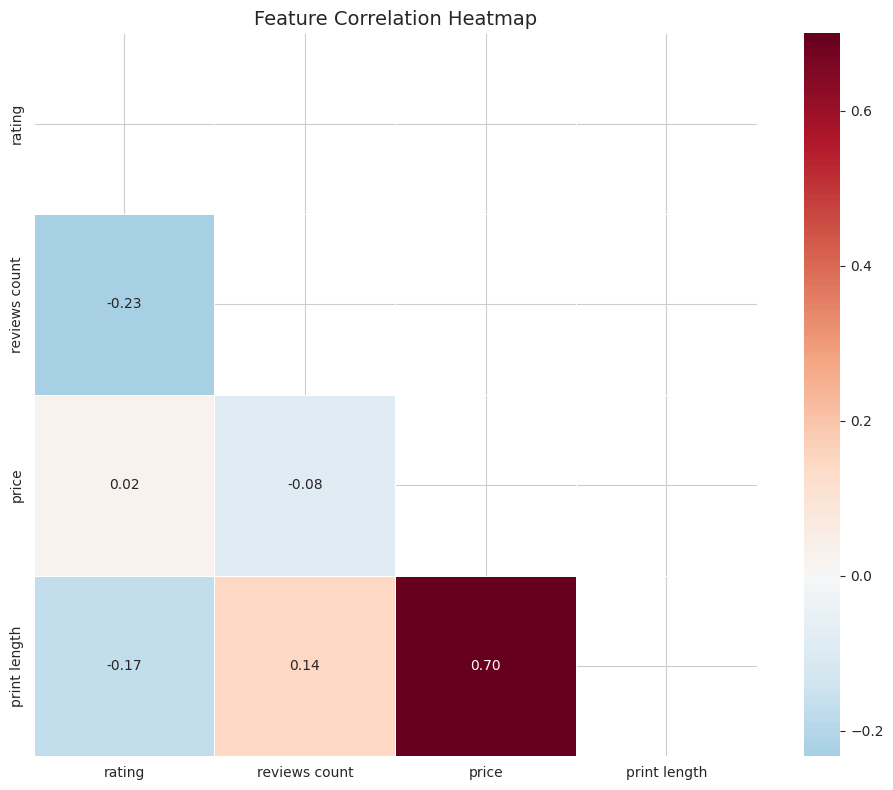


----------------------------------------
CATEGORICAL VARIABLES ANALYSIS
----------------------------------------


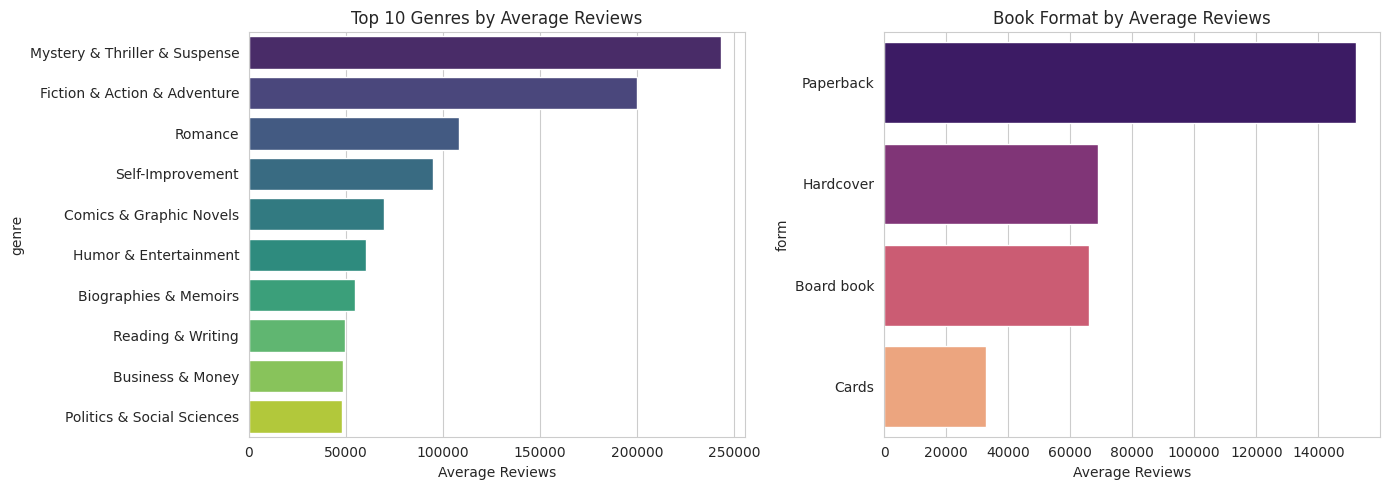


----------------------------------------
TIME-BASED ANALYSIS
----------------------------------------


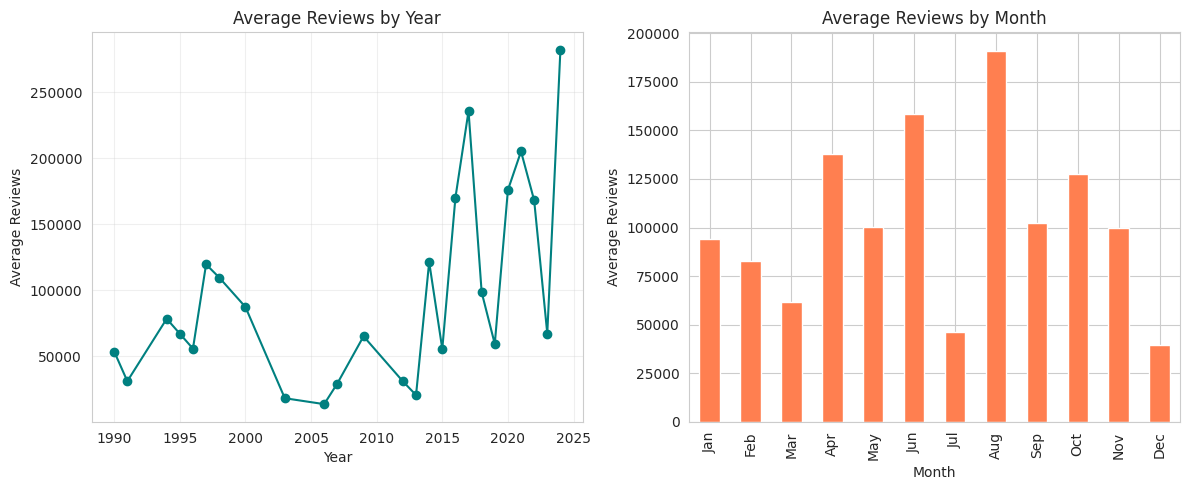


KEY EDA INSIGHTS SUMMARY

1. Target Variable (Reviews Count) Characteristics:
   - Range: 3296 to 653111 reviews
   - Highly skewed (skewness: 1.96) - suggests log transformation needed
   - Most books have fewer reviews, with a long tail of popular books

2. Top Predictive Features (by correlation):
   - print length: 0.144 correlation with review count
   - price: -0.084 correlation with review count
   - rating: -0.233 correlation with review count

3. Categorical Insights:
   - Best performing genre: Mystery & Thriller & Suspense
   - Best performing format: Paperback
   - Most prolific author: Sarah J. Maas (5 books)

4. Price Analysis:
   - Price range: $1.88 to $52.62
   - Optimal price point: books around $10.94 tend to get more reviews

5. Data Quality Notes:
   - Missing values: 78 total missing cells
   - Duplicates: 0 duplicate rows

ENHANCED EDA COMPLETE


In [ ]:
# ========== 1) ENHANCED EDA FOR REGRESSION PROBLEM ==========
print("\n" + "="*60)
print("ENHANCED EDA FOR REVIEW COUNT PREDICTION")
print("="*60)

# Import required libraries if not already imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ========== UNIVARIATE ANALYSIS ==========
print("\n" + "-"*40)
print("UNIVARIATE ANALYSIS - TARGET VARIABLE")
print("-"*40)

# Distribution of target variable (reviews count)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with KDE
sns.histplot(df['reviews count'].dropna(), kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Review Counts', fontsize=12)
axes[0,0].set_xlabel('Number of Reviews')

# Boxplot
sns.boxplot(x=df['reviews count'], ax=axes[0,1], color='coral')
axes[0,1].set_title('Boxplot of Review Counts', fontsize=12)
axes[0,1].set_xlabel('Number of Reviews')

# Log transformation to handle skewness
df['log_reviews'] = np.log1p(df['reviews count'])  # log(1+x) to handle zeros
sns.histplot(df['log_reviews'].dropna(), kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Log-Transformed Review Counts', fontsize=12)
axes[1,0].set_xlabel('Log(Number of Reviews)')

# Q-Q plot of log-transformed
stats.probplot(df['log_reviews'].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot (Log Transformed)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Target variable statistics:")
print(f"Mean: {df['reviews count'].mean():.2f}")
print(f"Median: {df['reviews count'].median():.2f}")
print(f"Std Dev: {df['reviews count'].std():.2f}")
print(f"Skewness: {df['reviews count'].skew():.2f}")
print(f"Kurtosis: {df['reviews count'].kurt():.2f}")

# ========== BIVARIATE ANALYSIS ==========
print("\n" + "-"*40)
print("BIVARIATE ANALYSIS - RELATIONSHIPS WITH TARGET")
print("-"*40)

# Create figure for multiple plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Rating vs Reviews Count - FIXED: Added hue and legend=False
sns.boxplot(data=df, x='rating', y='reviews count', hue='rating', legend=False, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Rating vs Review Count', fontsize=12)
axes[0,0].set_yscale('log')  # Log scale due to wide range

# 2. Price vs Reviews Count
sns.scatterplot(data=df, x='price', y='reviews count', alpha=0.6, ax=axes[0,1], color='purple')
axes[0,1].set_title('Price vs Review Count', fontsize=12)
axes[0,1].set_yscale('log')

# Add trend line - handle potential NaN values
price_clean = df['price'].dropna()
reviews_clean = df['reviews count'].dropna()
if len(price_clean) > 0 and len(reviews_clean) > 0:
    z = np.polyfit(price_clean, reviews_clean, 1)
    p = np.poly1d(z)
    axes[0,1].plot(price_clean.sort_values(), p(price_clean.sort_values()), "r--", alpha=0.8)

# 3. Print Length vs Reviews Count (if exists)
if 'print length' in df.columns:
    df['print length'] = pd.to_numeric(df['print length'], errors='coerce')
    sns.scatterplot(data=df, x='print length', y='reviews count', alpha=0.6, ax=axes[0,2], color='orange')
    axes[0,2].set_title('Print Length vs Review Count', fontsize=12)
    axes[0,2].set_yscale('log')
else:
    axes[0,2].text(0.5, 0.5, 'Print Length data not available',
                   ha='center', va='center', transform=axes[0,2].transAxes)
    axes[0,2].set_title('Print Length (Not Available)', fontsize=12)

# 4. Book Format vs Reviews Count - FIXED: Added hue and legend=False
sns.boxplot(data=df, x='form', y='reviews count', hue='form', legend=False, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Book Format vs Review Count', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Top Authors by Average Reviews - FIXED: Added hue and legend=False
top_authors = df.groupby('author')['reviews count'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10).reset_index()
sns.barplot(data=top_authors, x='mean', y='author', hue='author', legend=False, ax=axes[1,1], palette='coolwarm')
axes[1,1].set_title('Top 10 Authors by Avg Review Count', fontsize=12)
axes[1,1].set_xlabel('Average Reviews')

# 6. Genre vs Reviews Count - FIXED: Convert to DataFrame and add hue
genre_stats = df.groupby('genre')['reviews count'].median().sort_values(ascending=False).head(10).reset_index()
genre_stats.columns = ['genre', 'median_reviews']
sns.barplot(data=genre_stats, x='median_reviews', y='genre', hue='genre', legend=False, ax=axes[1,2], palette='magma')
axes[1,2].set_title('Top 10 Genres by Median Reviews', fontsize=12)
axes[1,2].set_xlabel('Median Reviews')

plt.tight_layout()
plt.show()

# ========== CORRELATION ANALYSIS ==========
print("\n" + "-"*40)
print("CORRELATION ANALYSIS")
print("-"*40)

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')
if 'log_reviews' in numeric_cols:
    numeric_cols.remove('log_reviews')  # Don't include transformed target in correlation

# Calculate correlations with target
correlations = df[numeric_cols].corrwith(df['reviews count']).sort_values(ascending=False)
print("Correlation with Review Count:")
for col, corr in correlations.items():
    if col != 'reviews count':
        print(f"{col}: {corr:.3f}")

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# ========== CATEGORICAL VARIABLES ANALYSIS ==========
print("\n" + "-"*40)
print("CATEGORICAL VARIABLES ANALYSIS")
print("-"*40)

# Analyze categorical variables impact on reviews
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average reviews by genre - FIXED: Convert to DataFrame and add hue
genre_avg = df.groupby('genre')['reviews count'].mean().sort_values(ascending=False).head(10).reset_index()
genre_avg.columns = ['genre', 'avg_reviews']
sns.barplot(data=genre_avg, x='avg_reviews', y='genre', hue='genre', legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Average Reviews')
axes[0].set_xlabel('Average Reviews')

# Average reviews by format - FIXED: Convert to DataFrame and add hue
format_avg = df.groupby('form')['reviews count'].mean().sort_values(ascending=False).reset_index()
format_avg.columns = ['form', 'avg_reviews']
sns.barplot(data=format_avg, x='avg_reviews', y='form', hue='form', legend=False, ax=axes[1], palette='magma')
axes[1].set_title('Book Format by Average Reviews')
axes[1].set_xlabel('Average Reviews')

plt.tight_layout()
plt.show()

# ========== TIME-BASED ANALYSIS ==========
print("\n" + "-"*40)
print("TIME-BASED ANALYSIS")
print("-"*40)

# Extract year from publishing date if available
if 'publishing date' in df.columns:
    # Ensure publishing date is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['publishing date']):
        # Try to convert to datetime
        df['publishing date'] = pd.to_datetime(df['publishing date'], errors='coerce')

    if pd.api.types.is_datetime64_any_dtype(df['publishing date']):
        df['year'] = df['publishing date'].dt.year
        df['month'] = df['publishing date'].dt.month

        # Reviews by year
        yearly_reviews = df.groupby('year')['reviews count'].mean().dropna()

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        yearly_reviews.plot(kind='line', marker='o', color='teal')
        plt.title('Average Reviews by Year')
        plt.xlabel('Year')
        plt.ylabel('Average Reviews')
        plt.grid(True, alpha=0.3)

        # Reviews by month
        monthly_reviews = df.groupby('month')['reviews count'].mean()
        plt.subplot(1, 2, 2)
        monthly_reviews.plot(kind='bar', color='coral')
        plt.title('Average Reviews by Month')
        plt.xlabel('Month')
        plt.ylabel('Average Reviews')
        plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

        plt.tight_layout()
        plt.show()

# ========== KEY INSIGHTS SUMMARY ==========
print("\n" + "="*60)
print("KEY EDA INSIGHTS SUMMARY")
print("="*60)

print("\n1. Target Variable (Reviews Count) Characteristics:")
print(f"   - Range: {df['reviews count'].min():.0f} to {df['reviews count'].max():.0f} reviews")
print(f"   - Highly skewed (skewness: {df['reviews count'].skew():.2f}) - suggests log transformation needed")
print(f"   - Most books have fewer reviews, with a long tail of popular books")

print("\n2. Top Predictive Features (by correlation):")
top_corrs = correlations.drop('reviews count').head(5)
for feat, corr in top_corrs.items():
    print(f"   - {feat}: {corr:.3f} correlation with review count")

print("\n3. Categorical Insights:")
top_genre = df.groupby('genre')['reviews count'].mean().idxmax()
top_format = df.groupby('form')['reviews count'].mean().idxmax()
print(f"   - Best performing genre: {top_genre}")
print(f"   - Best performing format: {top_format}")
print(f"   - Most prolific author: {df['author'].value_counts().index[0]} ({df['author'].value_counts().iloc[0]} books)")

print("\n4. Price Analysis:")
print(f"   - Price range: ${df['price'].min():.2f} to ${df['price'].max():.2f}")
print(f"   - Optimal price point: books around ${df[df['reviews count'] > df['reviews count'].median()]['price'].median():.2f} tend to get more reviews")

print("\n5. Data Quality Notes:")
print(f"   - Missing values: {df.isna().sum().sum()} total missing cells")
print(f"   - Duplicates: {df.duplicated().sum()} duplicate rows")

print("\n" + "="*60)
print("ENHANCED EDA COMPLETE")
print("="*60)